Stage 5 — Classification

In this stage, machine learning classification models are implemented to predict customer churn. Two different algorithms are used and compared: Decision Tree and Support Vector Machine (SVM).

The main objective is to evaluate how different models perform on the same dataset and identify the most suitable model for churn prediction based on performance metrics such as accuracy, precision, recall, and F1-score.

In [1]:
#import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Decision Tree

In [2]:
X_train = pd.read_csv("../data/X_train_reduced.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [3]:
weak_features = [
    'MultipleLines_Yes',
    'PhoneService',
    'gender',
    'MultipleLines_No phone service'
]

X_test = X_test.drop(columns=weak_features)

In [4]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4930, 26)
X_test shape: (2113, 26)
y_train shape: (4930, 1)
y_test shape: (2113, 1)


In [5]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [6]:
# Predict on test set
y_pred_dt = dt_model.predict(X_test)

print(y_pred_dt[:10])

[1 0 1 0 0 0 0 0 0 0]


In [7]:
# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Precision
dt_precision = precision_score(y_test, y_pred_dt)

# Recall
dt_recall = recall_score(y_test, y_pred_dt)

# F1-score
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

Decision Tree Performance:
Accuracy: 0.7870326549929011
Precision: 0.6121212121212121
Recall: 0.5401069518716578
F1-score: 0.5738636363636364


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[1360  192]
 [ 258  303]]


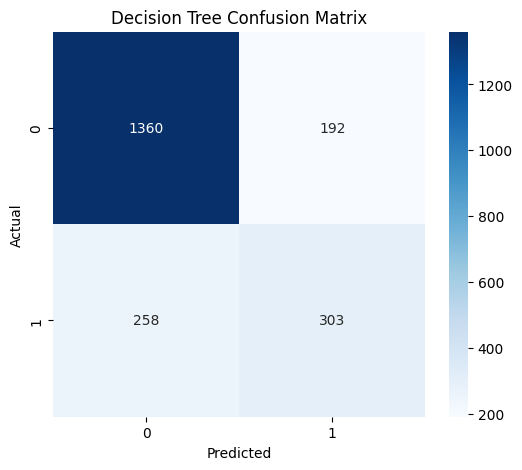

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
3                           tenure    0.406407
7      InternetService_Fiber optic    0.324597
6                     TotalCharges    0.064464
8               InternetService_No    0.041480
24  PaymentMethod_Electronic check    0.036845
22               Contract_Two year    0.032958
21               Contract_One year    0.031214
4                 PaperlessBilling    0.019529
5                   MonthlyCharges    0.017378
10              OnlineSecurity_Yes    0.007468


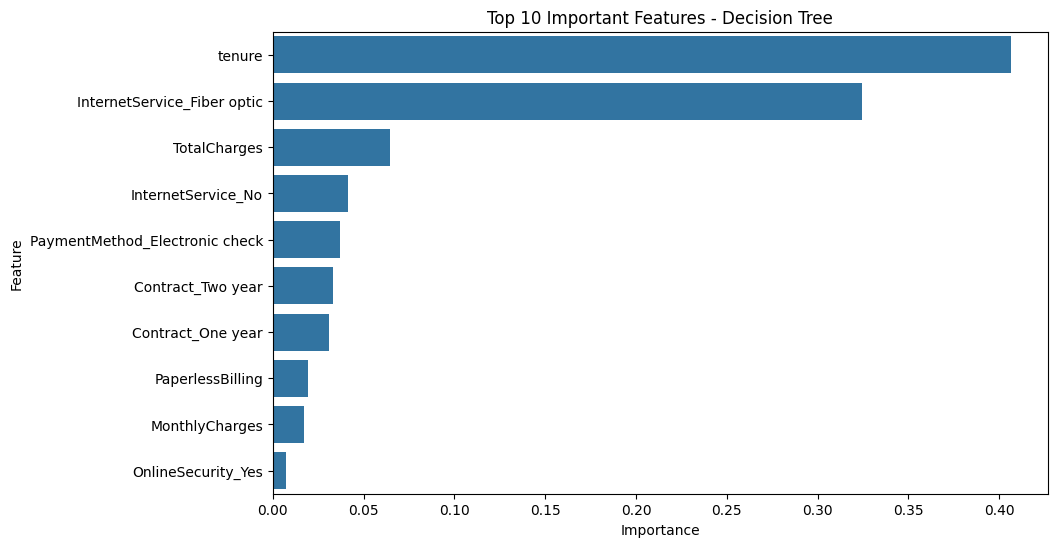

In [13]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Decision Tree")

plt.show()

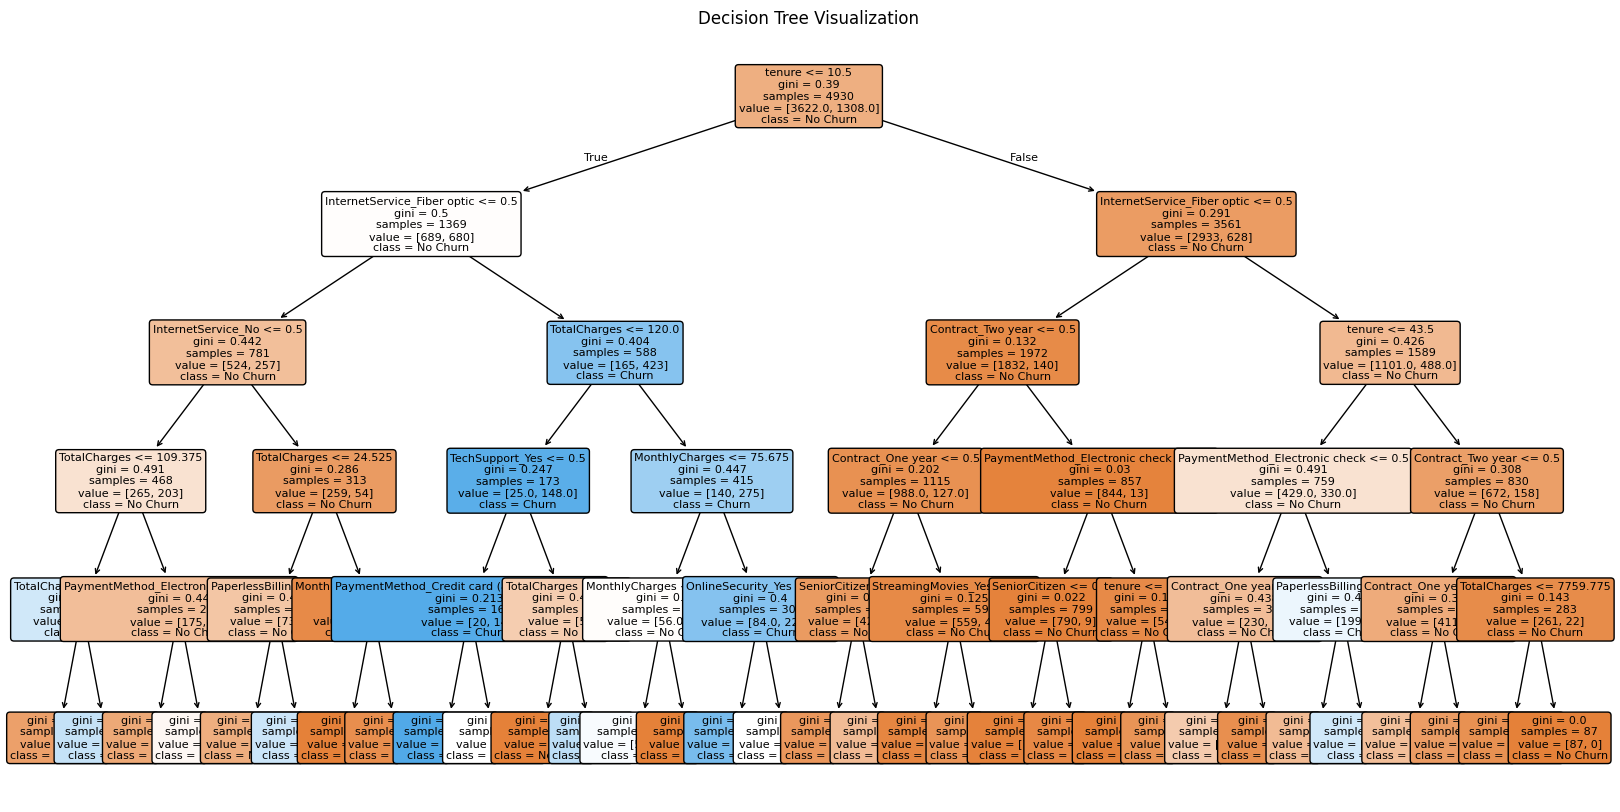

In [14]:
# Plot Decision Tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.show()

#SVM Classifier

In [15]:
# Load scaled datasets

X_train_scaled = pd.read_csv("../data/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/X_test_scaled.csv")

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [16]:
weak_features = [
    'MultipleLines_Yes',
    'PhoneService',
    'gender',
    'MultipleLines_No phone service'
]

X_train_scaled = X_train_scaled.drop(columns=weak_features)
X_test_scaled = X_test_scaled.drop(columns=weak_features)

In [17]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4930, 26)
(2113, 26)


In [18]:
# Create SVM model

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

In [19]:
# Train SVM model

svm_model.fit(X_train_scaled, y_train.values.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
# Predict using SVM

y_pred_svm = svm_model.predict(X_test_scaled)

print(y_pred_svm[:10])

[1 0 1 0 0 0 0 0 0 0]


In [21]:
# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

# Precision
svm_precision = precision_score(y_test, y_pred_svm)

# Recall
svm_recall = recall_score(y_test, y_pred_svm)

# F1-score
svm_f1 = f1_score(y_test, y_pred_svm)

print("SVM Performance:")
print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)

SVM Performance:
Accuracy: 0.7969711310932324
Precision: 0.6594202898550725
Recall: 0.48663101604278075
F1-score: 0.56


In [22]:
# Confusion Matrix

svm_cm = confusion_matrix(y_test, y_pred_svm)

print(svm_cm)

[[1411  141]
 [ 288  273]]


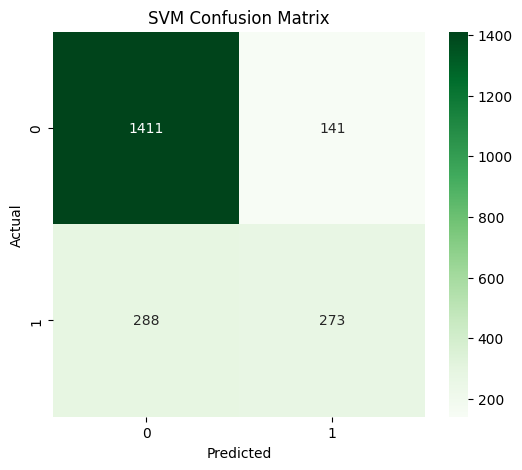

In [23]:
plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==============================
# Stage 6 - Model Evaluation
# ==============================

In [24]:
# Create comparison table

results = pd.DataFrame({
    "Model": ["Decision Tree", "SVM"],
    "Accuracy": [dt_accuracy, svm_accuracy],
    "Precision": [dt_precision, svm_precision],
    "Recall": [dt_recall, svm_recall],
    "F1-score": [dt_f1, svm_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.787033,0.612121,0.540107,0.573864
1,SVM,0.796971,0.659420,0.486631,0.560000


In [25]:
results_rounded = results.copy()

results_rounded.iloc[:, 1:] = (
    results_rounded.iloc[:, 1:].round(3)
)

results_rounded

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.787,0.612,0.540,0.574
1,SVM,0.797,0.659,0.487,0.560


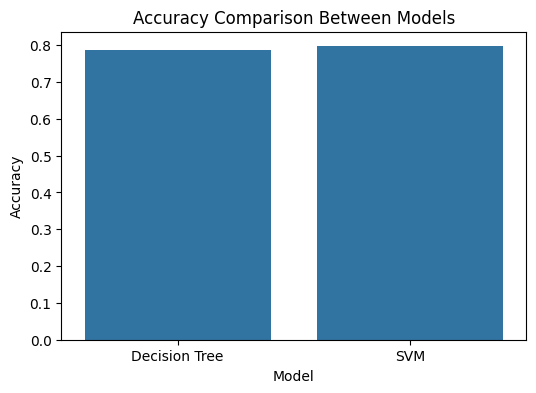

In [26]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison Between Models")

plt.show()

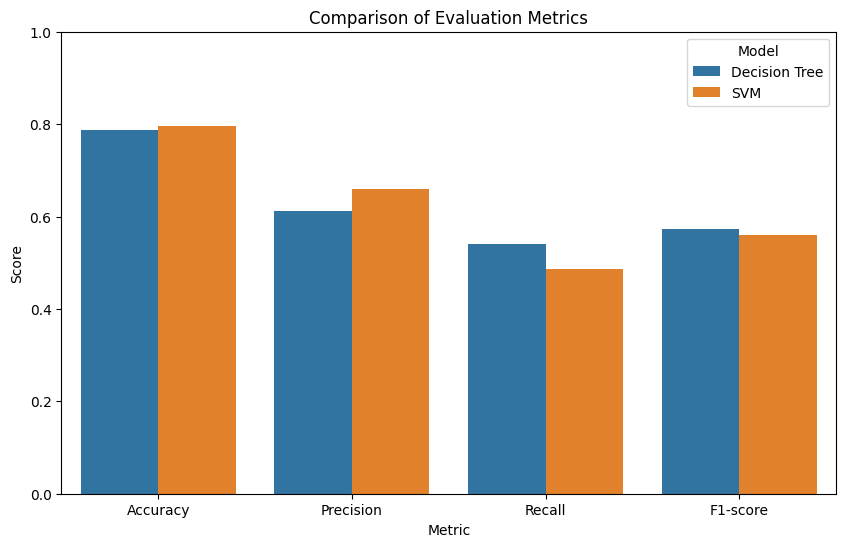

In [27]:
results_melted = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Comparison of Evaluation Metrics")

plt.ylim(0,1)

plt.show()

In [29]:
best_model = results.loc[
    results["F1-score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Decision Tree
Accuracy          0.787033
Precision         0.612121
Recall            0.540107
F1-score          0.573864
Name: 0, dtype: object


The evaluation results showed that both models achieved good performance in predicting customer churn.

The SVM classifier achieved slightly higher accuracy and precision. However, the Decision Tree classifier achieved better recall and F1-score, making it more effective in identifying churn customers.

Since customer churn prediction focuses on detecting customers who are likely to leave the company, recall and F1-score are considered very important metrics.

Overall, the Decision Tree model provided a better balance between interpretability and predictive performance.